# Spotify Popularity Prediction Regression Model

## our first machine learning model will model relations between the tags given by spotify on their songs, and predict what types of songs have a higher likelihood of being popular

## Trial 1: Linear Regression, audio features only

### Load Dataset

In [ ]:
import duckdb
from datasets import load_dataset

ds = load_dataset("GildasLeDrogoff/spotify-huge-track-analysis-dataset", split="train")
tbl = ds.data.table  # memory-mapped Arrow, nothing loaded into RAM yet

df = duckdb.sql("""
    SELECT track_id,
           any_value(track_popularity) AS track_popularity,
           any_value(tempo) AS tempo,
           any_value(danceability) AS danceability,
           any_value(energy) AS energy,
           any_value(loudness) AS loudness,
           any_value(speechiness) AS speechiness,
           any_value(acousticness) AS acousticness,
           any_value(instrumentalness) AS instrumentalness,
           any_value(liveness) AS liveness,
           any_value(valence) AS valence,
           any_value(energy_danceability_score) AS energy_danceability_score
    FROM tbl TABLESAMPLE 500000 ROWS
    GROUP BY track_id
""").df()
print(len(df))

497372


In [ ]:
# Clean before splitting, so copies of the same song can't land in both train and test
features = df.columns.drop(["track_id", "track_popularity"])

print("feature-identical duplicates:", df.duplicated(subset=features).sum())
df = df.drop_duplicates(subset=features)

print(df.isna().sum())
df = df.dropna(subset=features, how="all")

empty = (df[features] == 0).all(axis=1)
print("all-zero rows:", empty.sum())
df = df[~empty]
print(len(df))

feature-identical duplicates: 1700
track_id                     0
track_popularity             0
tempo                        0
danceability                 0
energy                       0
loudness                     0
speechiness                  0
acousticness                 0
instrumentalness             0
liveness                     0
valence                      0
energy_danceability_score    0
dtype: int64
all-zero rows: 0
495672


In [ ]:
df.head


<bound method NDFrame.head of                       track_id  track_popularity    tempo  danceability  \
0       4rpeMWo125XcUrarKa4HJp                22  120.097         0.642   
1       4G7fXf9qNwZFhyHFD4091X                22  169.942         0.579   
2       1tAIZ3D3O6InDVaN1FQRiu                 4  105.168         0.221   
3       0GkJFz8zRwy1E1Tk4CmHKb                15  119.937         0.577   
4       0moYWTRiR3xTnDp7jZllkk                 2   67.354         0.407   
...                        ...               ...      ...           ...   
497367  4NJk55JKS4UnOn4mgh2Grr                 2  149.381         0.356   
497368  235BJdXKzhCR2Ssx0gBJCd                 3   80.381         0.379   
497369  4XTcLkkD7hptijNKEyaNhL                 1   87.305         0.245   
497370  6pmGWWugqyIFWutnqca9YH                 2  115.101         0.481   
497371  3T3jGsKEGHaki8oYQ64FZ1                 8  139.661         0.320   

        energy  loudness  speechiness  acousticness  instrumentalness

In [ ]:
df.describe()

,track_popularity,artist_popularity,log_artist_followers,duration_ms,explicit,mode,track_number,release_year,tempo,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,energy_danceability_score
count,497296.000000,497296.000000,497296.000000,4.972960e+05,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000,497296.000000
mean,8.598048,29.224432,7.835795,2.194772e+05,0.123691,0.620554,14.318116,2016.800113,118.285256,0.571300,0.520567,-11.602252,0.201982,0.418471,0.218433,0.209481,0.459278,0.310826
std,9.845510,20.245891,3.391678,1.386757e+05,0.329229,0.485250,33.731950,10.389381,30.776796,0.186833,0.273761,6.810953,0.295676,0.349931,0.357984,0.174104,0.262670,0.190954
min,1.000000,0.000000,0.000000,1.629200e+04,0.000000,0.000000,1.000000,1970.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,12.000000,5.537334,1.617330e+05,0.000000,0.000000,2.000000,2014.000000,93.872750,0.454000,0.296000,-15.350000,0.038800,0.066900,0.000000,0.101000,0.244000,0.159200
50%,5.000000,28.000000,7.702556,1.946930e+05,0.000000,1.000000,5.000000,2021.000000,118.122500,0.610000,0.531000,-9.829000,0.056900,0.363000,0.000072,0.136000,0.446000,0.302667
75%,12.000000,44.000000,10.104835,2.483200e+05,0.000000,1.000000,11.000000,2024.000000,138.008000,0.709000,0.749000,-6.599000,0.188000,0.746000,0.392000,0.272000,0.665000,0.455586
max,90.000000,100.000000,18.765506,5.887930e+06,1.000000,1.000000,1152.000000,2025.000000,248.033000,0.991000,1.000000,6.172000,0.972000,0.996000,1.000000,1.000000,1.000000,0.966225


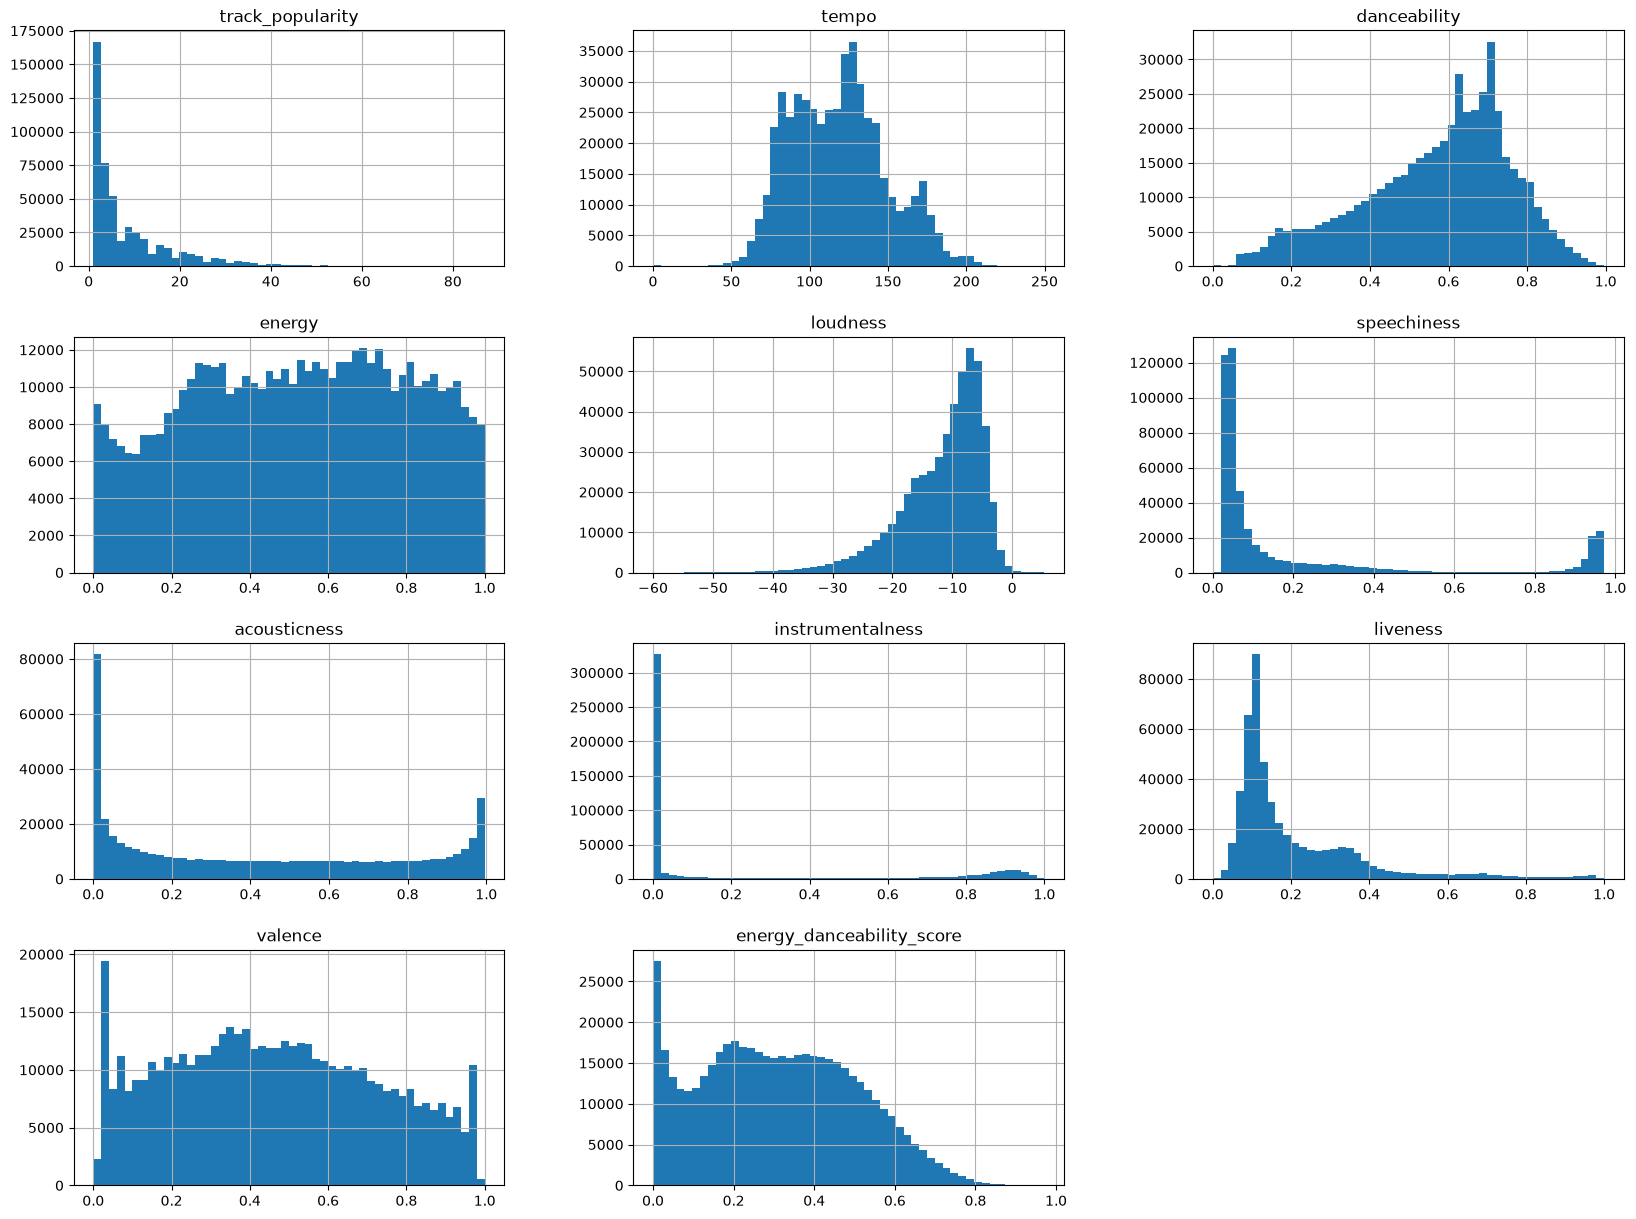

In [ ]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
import numpy as np
from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(identifier.encode()) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [ ]:
train_set, test_set = split_train_test_by_id(df, 0.2, 'track_id')

In [ ]:
len(train_set), len(test_set)

(396828, 98844)

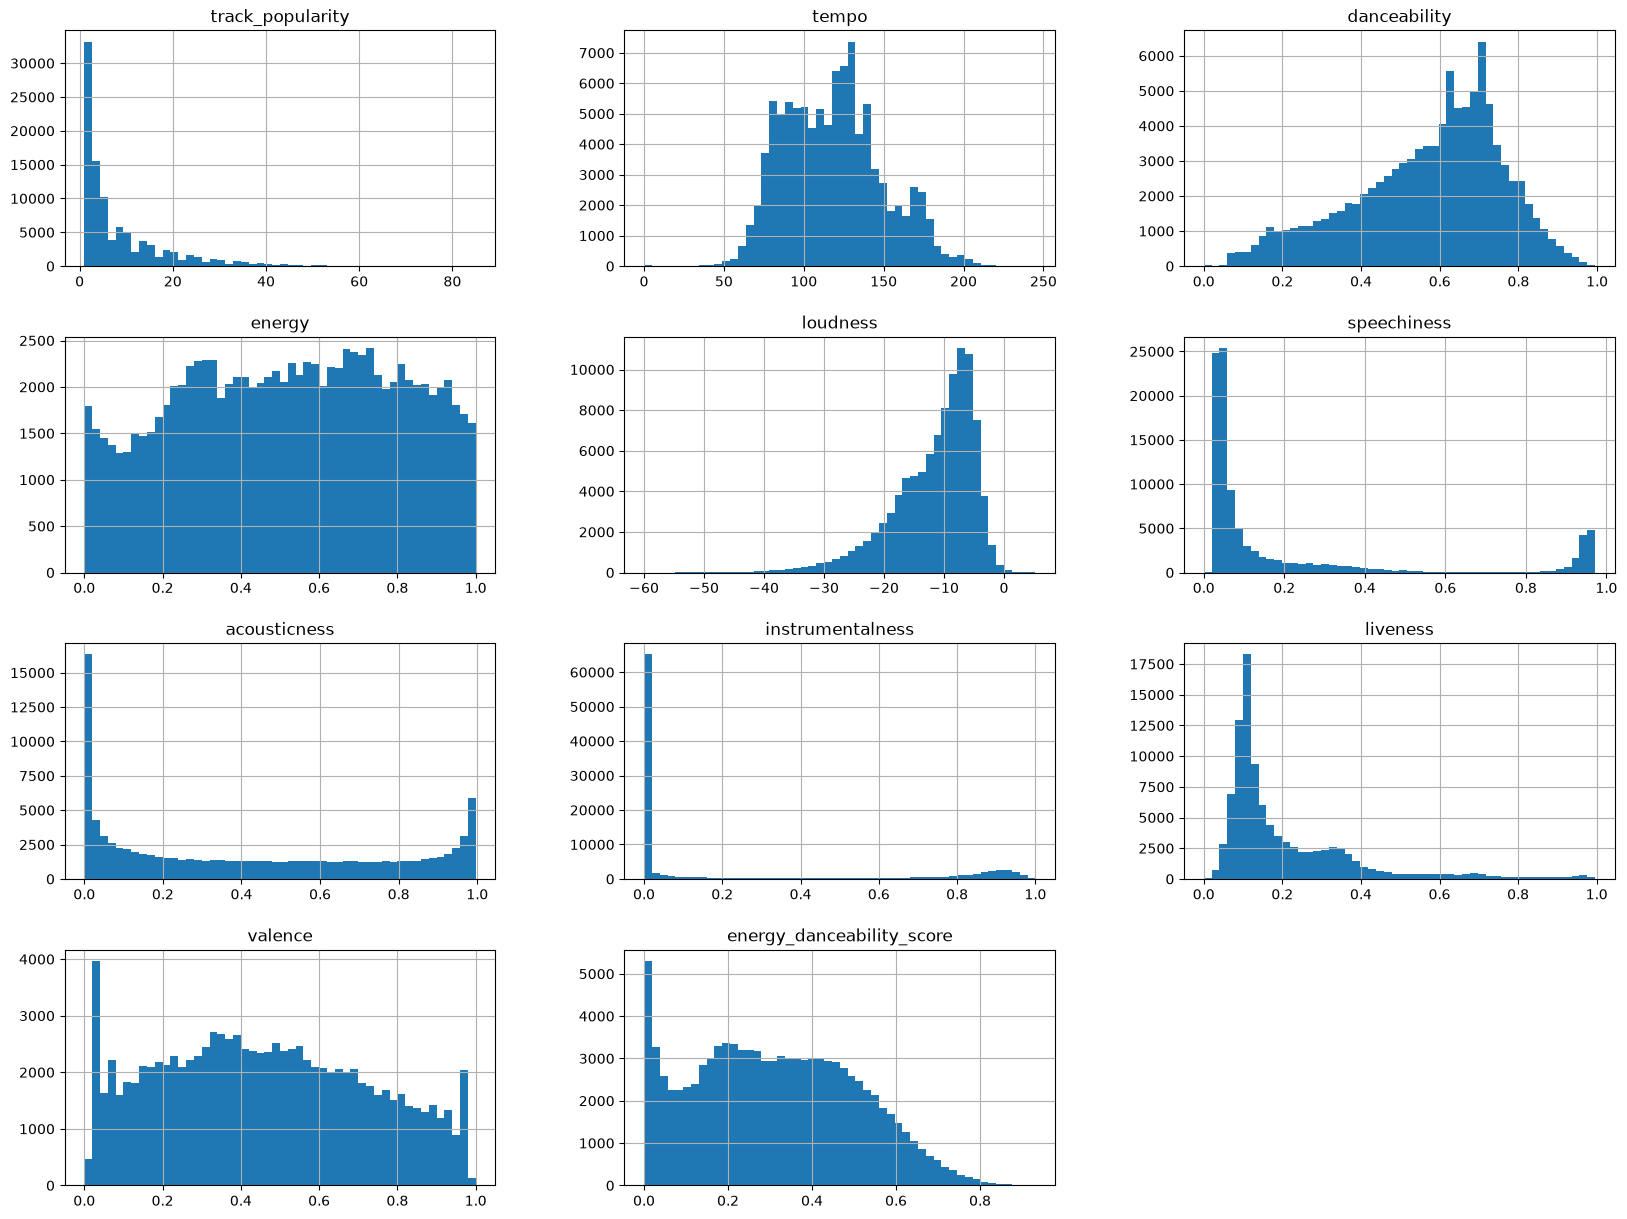

In [ ]:
test_set.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
music = train_set.copy()

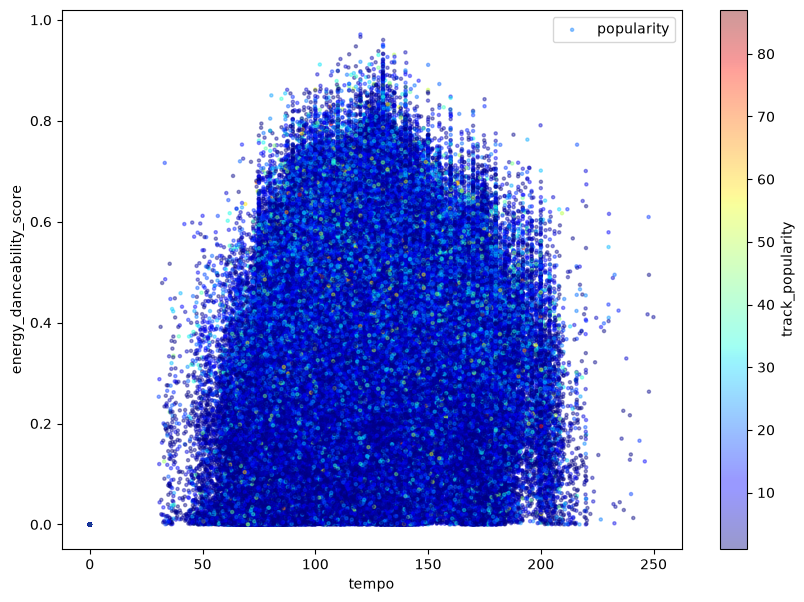

In [ ]:
music.plot(
    kind="scatter", x="tempo", y="energy_danceability_score", alpha=0.4,
    s = 5, label="popularity", figsize=(10, 7),
    c="track_popularity", cmap="jet", colorbar=True,
)
plt.legend()

In [ ]:
corr_matrix = music.corr(numeric_only=True)

In [ ]:
corr_matrix["track_popularity"].sort_values(ascending=False)


track_popularity             1.000000
loudness                     0.171817
energy_danceability_score    0.169607
energy                       0.148754
danceability                 0.095053
valence                      0.057025
tempo                        0.031440
liveness                    -0.002632
instrumentalness            -0.080609
speechiness                 -0.092661
acousticness                -0.108495
Name: track_popularity, dtype: float64

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
music_num = music.drop("track_id", axis=1)
imputer.fit(music_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['track_popularity','tempo','danceability',...,'liveness','valence', 'energy_danceability_score']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](11,)","[ 5. ,118.2 , 0.61,..., 0.14, 0.45, 0.3 ]"


In [ ]:
X = imputer.transform(music_num)

In [ ]:
import pandas as pd

music_tr = pd.DataFrame(X, columns=music_num.columns)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

# Separate the target so it doesn't get scaled or used as a feature
music_labels = train_set["track_popularity"].copy()
music_num = train_set.drop(["track_id", "track_popularity"], axis=1)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('minmax_scaler', MinMaxScaler()),
])

# fit on training data only; later use num_pipeline.transform(...) on the test set, never fit_transform
music_num_tr = num_pipeline.fit_transform(music_num)

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(music_num_tr, music_labels)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-0.02, 0.35,-3.05,..., 0.51,-2.22, 9.2 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.647
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[314.06,234.34,170.02,..., 73.48, 36.19, 23.79]"


In [ ]:
some_data = music_num.iloc[:5]
some_labels = music_labels.iloc[:5]
some_data_prepared = num_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predictions: [10.15484233  8.32272728  5.86995694 10.23146518 11.13936117]
Labels: [22, 22, 4, 15, 6]


In [ ]:
from sklearn.metrics import mean_squared_error

music_predictions = lin_reg.predict(music_num_tr)
lin_mse = mean_squared_error(music_labels, music_predictions)
lin_rmse = np.sqrt(lin_mse)
print("RMSE:", lin_rmse)

RMSE: 9.641042245831358


In [ ]:
from sklearn.metrics import r2_score
print("Baseline RMSE (always predict mean):", music_labels.std())
print("R²:", r2_score(music_labels, music_predictions))

Baseline RMSE (always predict mean): 9.857281282275686
R²: 0.04339032900391859


## Trial 2: Linear Regression, audio + artist/track features

In [ ]:
# Left out on purpose: album_popularity, track_vs_album_popularity, album_vs_artist_popularity
# are computed from track popularity itself -> they'd leak the answer.
df = duckdb.sql("""
    SELECT track_id,
           any_value(track_popularity) AS track_popularity,
           max(artist_popularity) AS artist_popularity,               -- one row per artist, keep the biggest
           ln(1 + max(artist_followers)) AS log_artist_followers,      -- log: followers range 0 to ~100M
           any_value(duration_ms) AS duration_ms,
           any_value(explicit)::INT AS explicit,
           any_value(mode) AS mode,
           any_value(track_number) AS track_number,
           year(any_value(album_release_date)) AS release_year,
           any_value(tempo) AS tempo,
           any_value(danceability) AS danceability,
           any_value(energy) AS energy,
           any_value(loudness) AS loudness,
           any_value(speechiness) AS speechiness,
           any_value(acousticness) AS acousticness,
           any_value(instrumentalness) AS instrumentalness,
           any_value(liveness) AS liveness,
           any_value(valence) AS valence,
           any_value(energy_danceability_score) AS energy_danceability_score
    FROM tbl TABLESAMPLE 500000 ROWS
    GROUP BY track_id
""").df()
print(len(df))

497296


In [ ]:
train_set, test_set = split_train_test_by_id(df, 0.2, 'track_id')

music_labels = train_set["track_popularity"].copy()
music_num = train_set.drop(["track_id", "track_popularity"], axis=1)
music_num_tr = num_pipeline.fit_transform(music_num)

train_set.corr(numeric_only=True)["track_popularity"].sort_values(ascending=False)

track_popularity             1.000000
artist_popularity            0.342414
log_artist_followers         0.292334
loudness                     0.170900
energy_danceability_score    0.167489
energy                       0.148078
danceability                 0.092270
explicit                     0.074443
valence                      0.059546
release_year                 0.051809
tempo                        0.031194
liveness                    -0.002461
mode                        -0.023599
duration_ms                 -0.025119
instrumentalness            -0.082740
speechiness                 -0.093162
acousticness                -0.108338
track_number                -0.128377
Name: track_popularity, dtype: float64

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(music_num_tr, music_labels)

music_predictions = lin_reg.predict(music_num_tr)
print("RMSE:", np.sqrt(mean_squared_error(music_labels, music_predictions)))
print("Baseline RMSE (always predict mean):", music_labels.std())
print("R²:", r2_score(music_labels, music_predictions))

RMSE: 8.80936560544567
Baseline RMSE (always predict mean): 9.865298835042228
R²: 0.2026116804564304


## Trial 3: Linear Regression, dropping weak features

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

corr = train_set.corr(numeric_only=True)["track_popularity"].drop("track_popularity").abs()
weak = corr[corr < 0.05].index.tolist()  # barely any link to popularity
print("Dropping:", weak)

music_num_kept = music_num.drop(columns=weak)
music_num_kept_tr = clone(num_pipeline).fit_transform(music_num_kept)  # clone: don't overwrite num_pipeline

Dropping: ['duration_ms', 'mode', 'tempo', 'liveness']


In [ ]:
for name, X in [("All features", music_num_tr), ("Weak features dropped", music_num_kept_tr)]:
    scores = cross_val_score(LinearRegression(), X, music_labels, scoring="neg_mean_squared_error", cv=5)
    print(f"{name}: CV RMSE {np.sqrt(-scores).mean():.4f}  ({X.shape[1]} features)")

All features: CV RMSE 8.8098  (17 features)
Weak features dropped: CV RMSE 8.8135  (13 features)


## Trial 4: Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Std:", scores.std())

# 100k rows keeps the tree models fast; raise it if you have time to wait
X_sub, y_sub = music_num_tr[:100_000], music_labels[:100_000]

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_sub, y_sub)
print("Training RMSE:", np.sqrt(mean_squared_error(y_sub, tree_reg.predict(X_sub))))

Training RMSE: 0.09418067742376883


In [ ]:
tree_scores = cross_val_score(tree_reg, X_sub, y_sub, scoring="neg_mean_squared_error", cv=5)
print("Decision tree:")
display_scores(np.sqrt(-tree_scores))

lin_scores = cross_val_score(lin_reg, X_sub, y_sub, scoring="neg_mean_squared_error", cv=5)
print("\nLinear regression:")
display_scores(np.sqrt(-lin_scores))

Decision tree:
Scores: [11.82503277 11.81891492 11.78681838 11.73565987 11.75527382]
Mean: 11.784339951242828
Std: 0.034848436725314874

Linear regression:
Scores: [8.72807457 8.86506663 8.80388853 8.74269505 8.76970429]
Mean: 8.781885813076936
Std: 0.04895533176454356


## Trial 5: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=50, min_samples_leaf=5, n_jobs=-1, random_state=42)
forest_scores = cross_val_score(forest_reg, X_sub, y_sub, scoring="neg_mean_squared_error", cv=5)
display_scores(np.sqrt(-forest_scores))

Scores: [8.22304696 8.29075471 8.2854759  8.22974387 8.24079246]
Mean: 8.253962779808491
Std: 0.028504470135708948


## Trial 6: Grid Search over features, models and hyperparameters

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

audio_cols = ["tempo", "danceability", "energy", "loudness", "speechiness", "acousticness",
              "instrumentalness", "liveness", "valence", "energy_danceability_score"]
extra_cols = [c for c in music_num.columns if c not in audio_cols]

# "extra" can be switched between passthrough (use) and drop (ignore) -> Trial 1 vs Trial 2 features
full_pipeline = Pipeline([
    ("features", ColumnTransformer([("audio", "passthrough", audio_cols),
                                    ("extra", "passthrough", extra_cols)])),
    ("prep", Pipeline([('imputer', SimpleImputer(strategy="median")),
                       ('minmax_scaler', MinMaxScaler())])),
    ("model", LinearRegression()),
])

param_grid = [
    {"features__extra": ["passthrough", "drop"], "model": [LinearRegression()]},
    {"features__extra": ["passthrough", "drop"], "model": [DecisionTreeRegressor(random_state=42)],
     "model__max_depth": [5, 10, 20]},
    {"features__extra": ["passthrough", "drop"],
     "model": [RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)],
     "model__max_features": [4, 8], "model__min_samples_leaf": [1, 5]},
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring="neg_mean_squared_error", verbose=2)
grid_search.fit(music_num.iloc[:100_000], music_labels.iloc[:100_000])

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END features__extra=passthrough, model=LinearRegression(); total time=   0.1s
[CV] END features__extra=passthrough, model=LinearRegression(); total time=   0.2s
[CV] END features__extra=passthrough, model=LinearRegression(); total time=   0.1s
[CV] END .....features__extra=drop, model=LinearRegression(); total time=   0.1s
[CV] END .....features__extra=drop, model=LinearRegression(); total time=   0.1s
[CV] END .....features__extra=drop, model=LinearRegression(); total time=   0.1s
[CV] END features__extra=passthrough, model=DecisionTreeRegressor(random_state=42), model__max_depth=5; total time=   0.4s
[CV] END features__extra=passthrough, model=DecisionTreeRegressor(random_state=42), model__max_depth=5; total time=   0.4s
[CV] END features__extra=passthrough, model=DecisionTreeRegressor(random_state=42), model__max_depth=5; total time=   0.4s
[CV] END features__extra=passthrough, model=DecisionTreeRegressor(random_state

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'features__extra': ['passthrough', 'drop'], 'model': [LinearRegression()]}, {'features__extra': ['passthrough', 'drop'], 'model': [DecisionTreeR...ndom_state=42)], 'model__max_depth': [5, 10, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscor

In [ ]:
print("Best:", grid_search.best_params_)
print("Best CV RMSE:", np.sqrt(-grid_search.best_score_))

results = pd.DataFrame(grid_search.cv_results_)
results["rmse"] = np.sqrt(-results["mean_test_score"])
results[["params", "rmse"]].sort_values("rmse")

Best: {'features__extra': 'passthrough', 'model': RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42), 'model__max_features': 8, 'model__min_samples_leaf': 5}
Best CV RMSE: 8.214347688925013


,params,rmse
11,"{'features__extra': 'passthrough', 'model': Ra...",8.214348
9,"{'features__extra': 'passthrough', 'model': Ra...",8.227171
10,"{'features__extra': 'passthrough', 'model': Ra...",8.298707
8,"{'features__extra': 'passthrough', 'model': Ra...",8.301711
2,"{'features__extra': 'passthrough', 'model': De...",8.527674
3,"{'features__extra': 'passthrough', 'model': De...",8.693755
0,"{'features__extra': 'passthrough', 'model': Li...",8.784224
5,"{'features__extra': 'drop', 'model': DecisionT...",9.606439
13,"{'features__extra': 'drop', 'model': RandomFor...",9.615966
1,"{'features__extra': 'drop', 'model': LinearReg...",9.641759


In [ ]:
# Final check on the test set: only run this once, at the very end
final_model = grid_search.best_estimator_

X_test = test_set.drop(["track_id", "track_popularity"], axis=1)
y_test = test_set["track_popularity"].copy()

final_predictions = final_model.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, final_predictions)))
print("Test R²:", r2_score(y_test, final_predictions))

Test RMSE: 8.22024878735025
Test R²: 0.3045805830784809


In [ ]:
# best_estimator_ is the whole pipeline, the forest sits in its "model" step
feature_importances = grid_search.best_estimator_.named_steps["model"].feature_importances_

used_extra = grid_search.best_params_["features__extra"] == "passthrough"
feature_names = audio_cols + (extra_cols if used_extra else [])

sorted(zip(feature_importances, feature_names), reverse=True)

[(np.float64(0.18205730446675372), 'artist_popularity'),
 (np.float64(0.13309492921772642), 'track_number'),
 (np.float64(0.10863310253069118), 'log_artist_followers'),
 (np.float64(0.07674668626801474), 'loudness'),
 (np.float64(0.05015620844370937), 'energy'),
 (np.float64(0.04962408480716864), 'duration_ms'),
 (np.float64(0.0481943048303728), 'speechiness'),
 (np.float64(0.04719240793136358), 'release_year'),
 (np.float64(0.044449181805953336), 'acousticness'),
 (np.float64(0.044224396950726996), 'energy_danceability_score'),
 (np.float64(0.04313466262738288), 'valence'),
 (np.float64(0.04269156754542194), 'liveness'),
 (np.float64(0.042309108549507084), 'tempo'),
 (np.float64(0.04096910484993593), 'danceability'),
 (np.float64(0.03442291566857095), 'instrumentalness'),
 (np.float64(0.00661988696172701), 'explicit'),
 (np.float64(0.005480146544973429), 'mode')]

## Trial 7: Recursive Feature Elimination with the best model

In [ ]:
from sklearn.feature_selection import RFECV

# Same forest the grid search picked. max_features as a fraction (8/17 ≈ 0.5),
# because a fixed 8 breaks once fewer than 8 features are left.
best_forest = clone(grid_search.best_estimator_.named_steps["model"]).set_params(max_features=0.5)

# Drops the least important feature, retrains, repeats; cross-validates every step
rfecv = RFECV(best_forest, step=1, cv=3, scoring="neg_mean_squared_error", verbose=1)
rfecv.fit(X_sub, y_sub)

print("Best number of features:", rfecv.n_features_)
print("Kept:", list(music_num.columns[rfecv.support_]))
print("Dropped:", list(music_num.columns[~rfecv.support_]))

Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitt

In [ ]:
cv_mse = -rfecv.cv_results_["mean_test_score"]

pd.DataFrame({
    "n_features": rfecv.cv_results_["n_features"],
    "cv_rmse": np.sqrt(cv_mse),
    "cv_r2": 1 - cv_mse / y_sub.var(ddof=0),  # R² = 1 - MSE / variance of the labels
})

,n_features,cv_rmse,cv_r2
0,1,9.582999,0.047525
1,2,9.437810,0.076168
2,3,8.891065,0.180105
3,4,8.498654,0.250881
4,5,8.459607,0.257749
5,6,8.442265,0.260789
6,7,8.396377,0.268803
7,8,8.391796,0.269601
8,9,8.369748,0.273434
9,10,8.363706,0.274482
